In [6]:
import sys
import os
# 获取当前 notebook 所在目录的父目录的父目录（即项目根目录）
project_root = os.path.dirname(os.path.dirname(os.path.abspath('.')))
sys.path.append(project_root)

In [8]:
from util import Score_calculate as score
from transformers import T5Tokenizer, T5ForConditionalGeneration
import pandas as pd
from tqdm import tqdm
import torch

In [9]:
# === 2. 定义生成函数 ===
def generate_smiles_from_caption(caption, tokenizer, model, max_length=128):
    inputs = tokenizer(caption, return_tensors="pt", truncation=True).to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=max_length,
            num_beams=5,
            early_stopping=True
        )
    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return decoded.strip()

In [10]:
# 微调模型生成指标测试
tokenizer = T5Tokenizer.from_pretrained(R"/mnt/slowdisk/ZYH/LLMCP/CheckPoint/SingMolT5_base/checkpoint-323", model_max_length=128)
model = T5ForConditionalGeneration.from_pretrained(R'/mnt/slowdisk/ZYH/LLMCP/CheckPoint/SingMolT5_base/checkpoint-323')

# === 载入测试集 ===
df = pd.read_csv("/home/zhaoyiheng/LLM/FT_MolT5/dataset/V6/MolGen_Test.csv")  # 包含 Caption 和 SMILES 列
captions = df["Caption"].tolist()
true_smiles = df["SMILES"].tolist()

# === 设备设置 ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# === 生成 SMILES ===
ft_generated_smiles = []
for caption in tqdm(captions, desc="Generating SMILES"):
    pred = generate_smiles_from_caption(caption, tokenizer, model)
    ft_generated_smiles.append(pred)

# === 计算评价指标 ===
with score.suppress_rdkit_warnings():
    results = score.evaluate_batch(true_smiles, ft_generated_smiles)

score.result_output(results)

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Generating SMILES: 100%|██████████| 60/60 [00:20<00:00,  2.87it/s]



=== Evaluation Results (Average over Batch) ===
BLEU                  : 0.4539
Levenshtein Similarity: 0.5691
MACCS FTS             : 0.6233
RDK FTS               : 0.3267
Morgan FTS            : 0.4287
Validity              : 0.9833


In [11]:
# molt5指标测试
tokenizer = T5Tokenizer.from_pretrained(R"/home/zhaoyiheng/LLM/FT_MolT5/model/molT5baseCap2Sm", model_max_length=128)
model = T5ForConditionalGeneration.from_pretrained(R'/home/zhaoyiheng/LLM/FT_MolT5/model/molT5baseCap2Sm')

# === 载入测试集 ===
df = pd.read_csv("/home/zhaoyiheng/LLM/FT_MolT5/dataset/V6/MolGen_Test.csv")  # 包含 Caption 和 SMILES 列
captions = df["Caption"].tolist()
true_smiles = df["SMILES"].tolist()

# === 设备设置 ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# === 生成 SMILES ===
mt5_generated_smiles = []
for caption in tqdm(captions, desc="Generating SMILES"):
    pred = generate_smiles_from_caption(caption, tokenizer, model)
    mt5_generated_smiles.append(pred)

# === 计算评价指标 ===
with score.suppress_rdkit_warnings():
    results = score.evaluate_batch(true_smiles, mt5_generated_smiles)

score.result_output(results)

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
/usr/local/anaconda3/envs/zyhEnv/lib/python3.8/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
Generat


=== Evaluation Results (Average over Batch) ===
BLEU                  : 0.3833
Levenshtein Similarity: 0.4936
MACCS FTS             : 0.4220
RDK FTS               : 0.2362
Morgan FTS            : 0.2226
Validity              : 0.9167


In [12]:
# t5指标测试
tokenizer = T5Tokenizer.from_pretrained(R"/mnt/slowdisk/ZYH/LLMCP/t5base_cp2sm", model_max_length=128)
model = T5ForConditionalGeneration.from_pretrained(R'/mnt/slowdisk/ZYH/LLMCP/t5base_cp2sm')

# === 载入测试集 ===
df = pd.read_csv("/home/zhaoyiheng/LLM/FT_MolT5/dataset/V6/MolGen_Test.csv")  # 包含 Caption 和 SMILES 列
captions = df["Caption"].tolist()
true_smiles = df["SMILES"].tolist()

# === 设备设置 ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# === 生成 SMILES ===
t5_generated_smiles = []
for caption in tqdm(captions, desc="Generating SMILES"):
    pred = generate_smiles_from_caption(caption, tokenizer, model)
    t5_generated_smiles.append(pred)

# === 计算评价指标 ===
with score.suppress_rdkit_warnings():
    results = score.evaluate_batch(true_smiles, t5_generated_smiles)

score.result_output(results)

Generating SMILES: 100%|██████████| 60/60 [00:31<00:00,  1.89it/s]


=== Evaluation Results (Average over Batch) ===
BLEU                  : 0.4084
Levenshtein Similarity: 0.4893
MACCS FTS             : 0.2068
RDK FTS               : 0.1419
Morgan FTS            : 0.1191
Validity              : 0.6167


In [13]:
print(f"Model is on device: {model.device}")

Model is on device: cuda:0


In [14]:
print(ft_generated_smiles)

['C1=CN=CC=C1C#CC2=CC=NC=C2', 'C1=CN=CC=C1C#CC2=CC=NC=C2', 'C1=CN=CC=C1C#CC2=CC=NC=C2', 'C1=CC(=CC=C1C(=O)O)C(=O)O', 'C1=CC(=CC=C1C#CC2=CC=C(C=C2)C(=O)O)C(=O)O', 'C1=CC(=CC=C1C#CC2=CC=C(C=C2)C(=O)O)C(=O)O', 'C1=CC(=CC=C1S)S', 'C1=CC(=CC=C1S)S', 'C1=CC(=CC=C1S)S', 'C1=CC(=CC=C1N)N', 'C1=CC(=CC=C1N)N', 'C1=CC(=CC=C1N)N', 'CSC1=CC=C(C=C1)C#CC2=CC=CC=C2', 'CSC1=CC=C(C=C1)C#CC2=CC=C(C=C2)SC', 'CSC1=CC=C(C=C1)SC', 'C1=CN=CC=C1C#CS', 'C1=CN=CC=C1C#CS', 'C1=CN=CC=C1S', 'CC(=O)SC1=CC=NC=C1', 'CC(=O)SC1=CC=NC=C1', 'CC(=O)SC1=CC=NC=C1', 'CNC1=CC=C(NC)C=C1', 'CNC1=CC=C(NC)C=C1', 'CNC1=CC=C(NC)C=C1', 'C1=CC(=CC=C1C#N)C#N', 'C1=CC(=CC=C1C#N)C#N', 'C1=CC(=CC=C1C#N)C#N', 'CNC1=CC2=C(C=C1)C=C(I)C=C2', 'C1=CC2=C(C=CC3=C2C=CC(=C3)I)C=C1I', 'C1=CC2=C(C=C1I)C=C(I)C=C2I', 'CSC1=CC=C(C=C1)C2=CC=C(C=C2)SC', 'CSC1=CC=C(C=C1)C2=CC=C(C=C2)SC', 'CSC1=CC=C(C=C1)C2=CC=C(C=C2)SC', 'CSC1=CC=C(SC)C=C1', 'CSC1=CC=C(SC)C=C1', 'CSC1=CC=C(SC)C=C1', 'C1=CC(=CC=C1N)N', 'C1=CC(=CC=C1N)N', 'C1=CC(=CC=C1N)N', 'C1=CC(=CC=C1C2=C

In [15]:
print(mt5_generated_smiles)

['CC1=C(C(=C(C(=C1C)C=O)N=C=O)C)C', 'C1=CC=NC(=C1)C2=CC=NC=C2', 'CC1=C(C(=C(C(=C1C2=CC=CC=C2)C)C)C=C)C=C CNN', 'C1=CC=C(C=C1)C2=CC=CC=C2', 'C1=CC=C(C=C1)C2=CC=CC=C2', 'C1=CC(=CC=C1C2=CC=C(C=C2)OC3=CC=C(C=C3)C(=O)O)C4=CC=CC=C4', 'C1=CC=C2C(=C1)C(=O)C3=CC=CC=C3S(=O)(=O)O', 'C[C@H]1[C@@H]([C@H]([C@H]([C@@H](O1)NS(=O)(=O)C2=CC=CC=C2)C(=O)O)N', 'C1=CC=C2C(=C1)C=CC(=O)CCC2=C1', 'C1=CC=C(C=C1)N', 'C1=CC=C(C=C1)C2=CC=C(C=C2)N', 'C1=CC=C(C=C1)C2=CC=C(C=C2)N', 'CSC1=CC=C(C=C1)SC2=CC=CC=C2C(=O)O', 'CSCCCCCCCCCCN1C2=CC=CC=C2C(=C1)SC', 'CSCCC[C@@H](C(=O)O)N', 'C1=CC(=CN=C1)C2=CC(=CC=C2)S(=O)(=O)N', 'C1=CN=CC=C1S(=O)(=O)C2=CC=C(C=C2)N3CCCCC3', 'C1=CC=C2C(=C1)C(=O)N(C2=O)C(=O)O', 'C1=CC=C2C(=C1)C(=O)C=C(N2)C3=CC=CC=N3', 'C1=CC(=CN=C1)C(=O)S', 'C1=CC=C(C=C1)S(=O)(=O)N', 'CNC1=CC=CC=C1', 'C1=CC=C(C=C1)CN', 'CNC1=CC=CC=C1', 'C1=CC=C(C=C1)C(=O)C2=CC=CC=C2', 'C1=CC=C(C=C1)C(=O)NC2=CC=CC=C2', 'C1=CC=C(C=C1)C(=O)C2=CC=CC=C2', 'C1=CC=C2C(=C1)C=CC(=C2)I', 'C1=CC=C2C(=C1)C=CC=C2I', 'C1=CC=C(C=C1)C(=O)NCCCC3=CC

In [16]:
print(t5_generated_smiles)

['CC1=CC=C(C=C1)C(=O)CC2=CC=CC=C2', 'C1=CC=C(C=C1)C(=O)C2=CC=C(C=C2)N(C)C(=O)O', 'C1=CC=C(C=C1)C(=O)NC2=C(C=CC(=C2)C(=C3C=CC(=[N+](C)C)CC(=O)O)C4=CC=CC=C4', 'CC1=CC=C(C=C1)CCCC(=O)CC2=CC=CC=C2', 'C1=CC=C(C=C1)CCC(=O)CCC2=CC=CC=C2', 'CC1=CC=C(C=C1)C(=O)C2=CC=CC=C2', 'C1=CC2=C(C=C1S(=O)(=O)O)C(=C(C=C2S(=O)(=O)O)S(=O)(=O)O', 'C1=CC(=CC=C1C(=O)O)S(=O)(=O)O', 'C1=CC=C2C(=C1)C(=O)C3=C(C2=O)C(=C(C=C3O)S(=O)(=O)O)S(=O)(=O)O)O', 'C1=CC=C(C=C1)C2=CC=CC=C2', 'C1=CC=C(C=C1)C2=CC=C(C=C2)N)N', 'C1=CC=C(C=C1)C2=CC(=CC=C2)N2C3=CC=CC=C3', 'C=CCSC1=CC=CC=C1C(=O)[C@H](CSC2=CC=CC=C2)C(=O)O', 'C[Sb](C)(C)C1=CC=C(C=C1)C(=O)O', 'C=CCSC1=CC=CC=C1C(=O)N(C(=O)N(C(=O)N(C(=O)N)C(=O)O)C)C', 'C1=CC(=CN=C1)C2=CC=CC=C2', 'C1=CC(=NC2=C(C=C1)N=C(S2)C(=O)O', 'C1=CC(=CN=C1)C2=CC=CC=C2S(=O)(=O)O', 'CC(=O)OC1=CC=C(C=C1)C(=O)[O-]', 'CSC1=C(C(=CC=C1)OC)C(=O)C2=CC=C(O2)C(=O)O', 'CCSC=NCC1=C(C(=C(C=N1)C)C(=O)[O-])C', 'CC1=C(C(=CC=C1)C)C', 'C[C@@H]1CCC(=O)C2=C(C3=C(C=C(C=C3C=C2', 'CN1C(=C(C2=C1C(=O)C3=CC=CC=C3N2) CNC2=O)C', 'C1

Aromatic: C1=CN=CC=C1C#CC2=CC=NC=C2
Kekule:   C(#CC1=CC=NC=C1)C1=CC=NC=C1

Structure of C(#CC1=CC=NC=C1)C1=CC=NC=C1


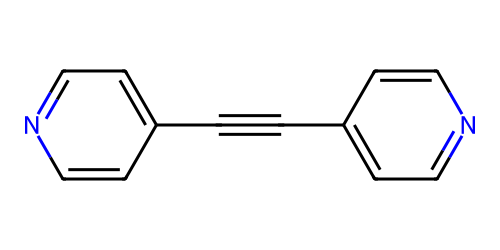

Aromatic: C1=CN=CC=C1C#CC2=CC=NC=C2
Kekule:   C(#CC1=CC=NC=C1)C1=CC=NC=C1

Structure of C(#CC1=CC=NC=C1)C1=CC=NC=C1


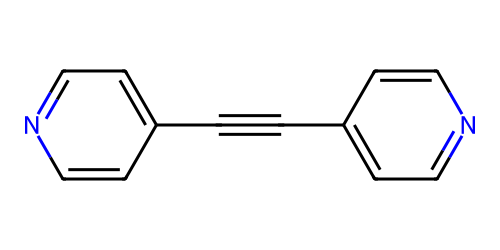

Aromatic: C1=CN=CC=C1C#CC2=CC=NC=C2
Kekule:   C(#CC1=CC=NC=C1)C1=CC=NC=C1

Structure of C(#CC1=CC=NC=C1)C1=CC=NC=C1


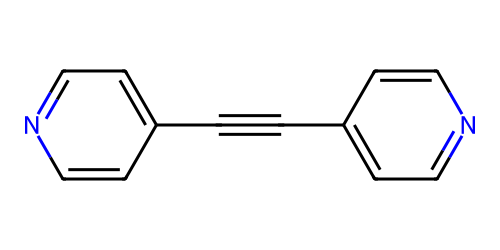

Aromatic: C1=CC(=CC=C1C(=O)O)C(=O)O
Kekule:   O=C(O)C1=CC=C(C(=O)O)C=C1

Structure of O=C(O)C1=CC=C(C(=O)O)C=C1


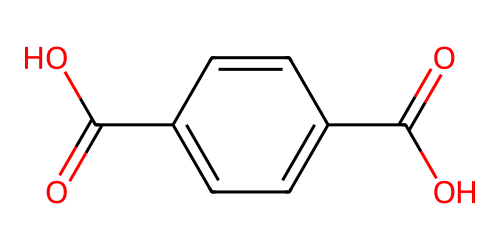

Aromatic: C1=CC(=CC=C1C#CC2=CC=C(C=C2)C(=O)O)C(=O)O
Kekule:   O=C(O)C1=CC=C(C#CC2=CC=C(C(=O)O)C=C2)C=C1

Structure of O=C(O)C1=CC=C(C#CC2=CC=C(C(=O)O)C=C2)C=C1


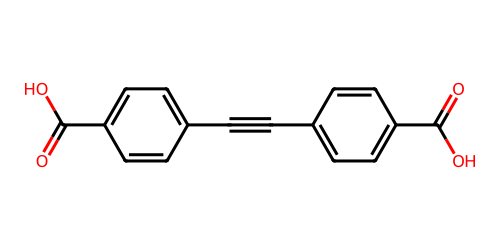

Aromatic: C1=CC(=CC=C1C#CC2=CC=C(C=C2)C(=O)O)C(=O)O
Kekule:   O=C(O)C1=CC=C(C#CC2=CC=C(C(=O)O)C=C2)C=C1

Structure of O=C(O)C1=CC=C(C#CC2=CC=C(C(=O)O)C=C2)C=C1


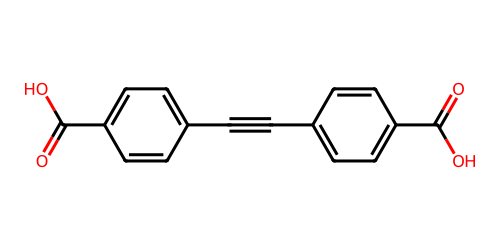

Aromatic: C1=CC(=CC=C1S)S
Kekule:   SC1=CC=C(S)C=C1

Structure of SC1=CC=C(S)C=C1


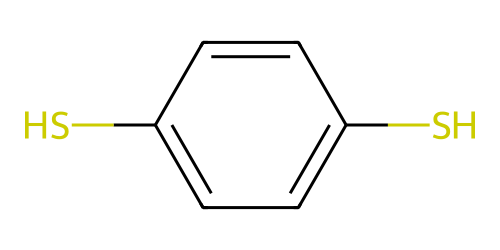

Aromatic: C1=CC(=CC=C1S)S
Kekule:   SC1=CC=C(S)C=C1

Structure of SC1=CC=C(S)C=C1


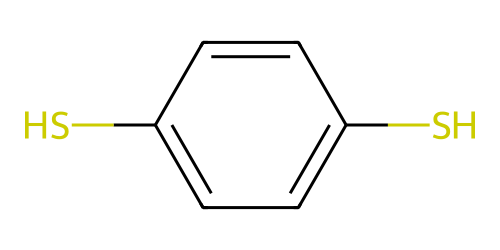

Aromatic: C1=CC(=CC=C1S)S
Kekule:   SC1=CC=C(S)C=C1

Structure of SC1=CC=C(S)C=C1


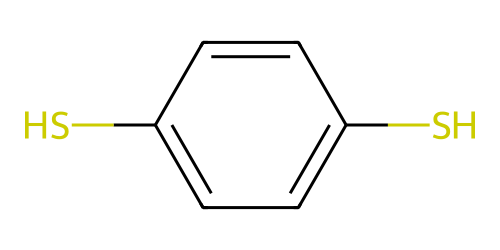

Aromatic: C1=CC(=CC=C1N)N
Kekule:   NC1=CC=C(N)C=C1

Structure of NC1=CC=C(N)C=C1


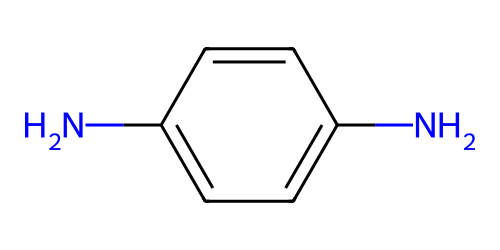

Aromatic: C1=CC(=CC=C1N)N
Kekule:   NC1=CC=C(N)C=C1

Structure of NC1=CC=C(N)C=C1


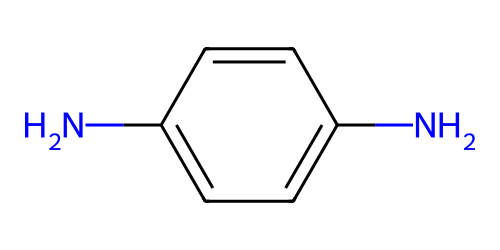

Aromatic: C1=CC(=CC=C1N)N
Kekule:   NC1=CC=C(N)C=C1

Structure of NC1=CC=C(N)C=C1


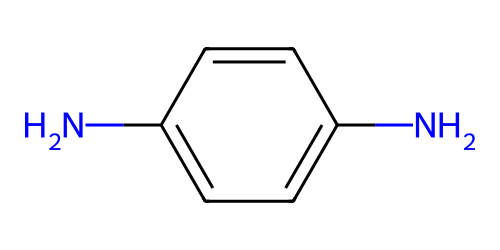

Aromatic: CSC1=CC=C(C=C1)C#CC2=CC=CC=C2
Kekule:   CSC1=CC=C(C#CC2=CC=CC=C2)C=C1

Structure of CSC1=CC=C(C#CC2=CC=CC=C2)C=C1


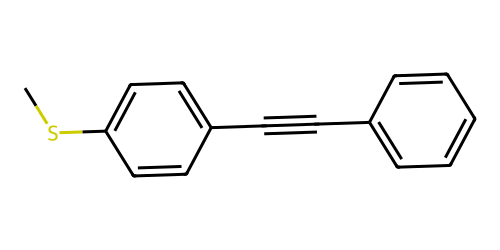

Aromatic: CSC1=CC=C(C=C1)C#CC2=CC=C(C=C2)SC
Kekule:   CSC1=CC=C(C#CC2=CC=C(SC)C=C2)C=C1

Structure of CSC1=CC=C(C#CC2=CC=C(SC)C=C2)C=C1


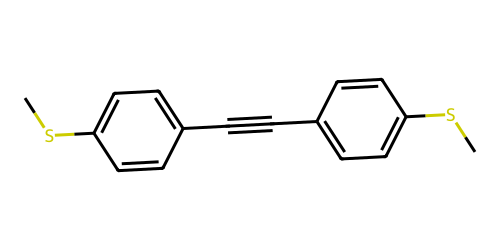

Aromatic: CSC1=CC=C(C=C1)SC
Kekule:   CSC1=CC=C(SC)C=C1

Structure of CSC1=CC=C(SC)C=C1


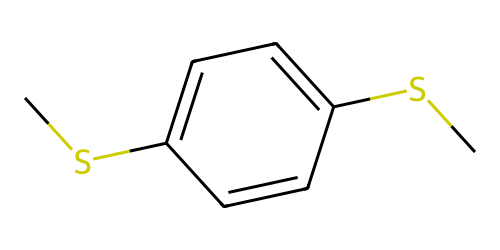

Aromatic: C1=CN=CC=C1C#CS
Kekule:   SC#CC1=CC=NC=C1

Structure of SC#CC1=CC=NC=C1


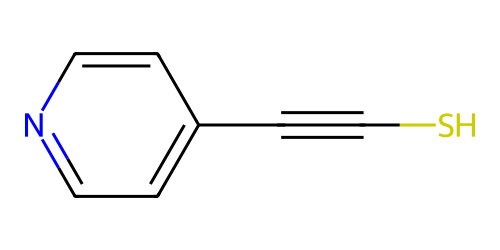

Aromatic: C1=CN=CC=C1C#CS
Kekule:   SC#CC1=CC=NC=C1

Structure of SC#CC1=CC=NC=C1


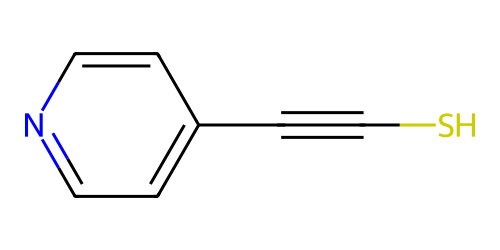

Aromatic: C1=CN=CC=C1S
Kekule:   SC1=CC=NC=C1

Structure of SC1=CC=NC=C1


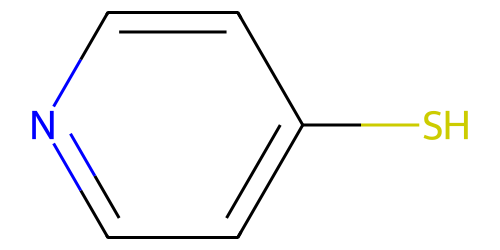

Aromatic: CC(=O)SC1=CC=NC=C1
Kekule:   CC(=O)SC1=CC=NC=C1

Structure of CC(=O)SC1=CC=NC=C1


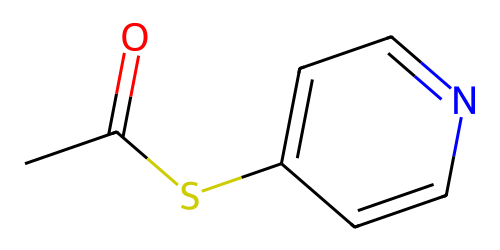

Aromatic: CC(=O)SC1=CC=NC=C1
Kekule:   CC(=O)SC1=CC=NC=C1

Structure of CC(=O)SC1=CC=NC=C1


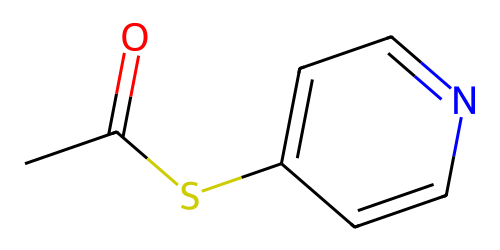

Aromatic: CC(=O)SC1=CC=NC=C1
Kekule:   CC(=O)SC1=CC=NC=C1

Structure of CC(=O)SC1=CC=NC=C1


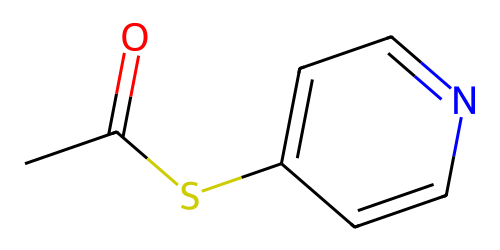

Aromatic: CNC1=CC=C(NC)C=C1
Kekule:   CNC1=CC=C(NC)C=C1

Structure of CNC1=CC=C(NC)C=C1


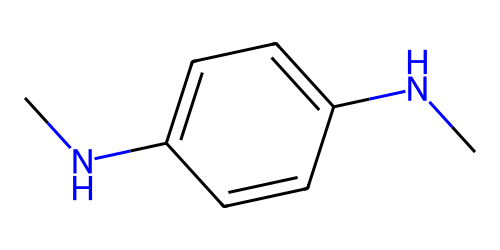

Aromatic: CNC1=CC=C(NC)C=C1
Kekule:   CNC1=CC=C(NC)C=C1

Structure of CNC1=CC=C(NC)C=C1


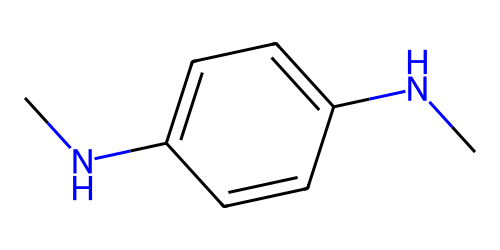

Aromatic: CNC1=CC=C(NC)C=C1
Kekule:   CNC1=CC=C(NC)C=C1

Structure of CNC1=CC=C(NC)C=C1


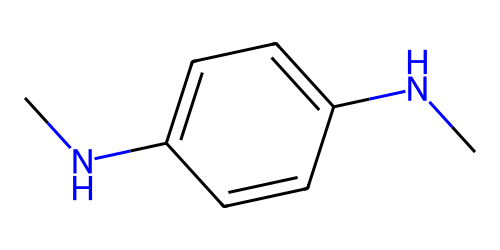

Aromatic: C1=CC(=CC=C1C#N)C#N
Kekule:   N#CC1=CC=C(C#N)C=C1

Structure of N#CC1=CC=C(C#N)C=C1


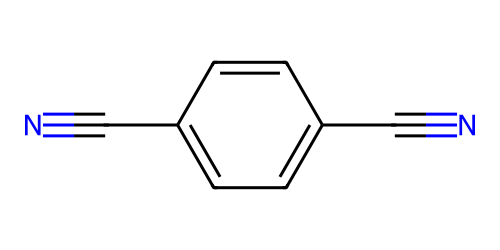

Aromatic: C1=CC(=CC=C1C#N)C#N
Kekule:   N#CC1=CC=C(C#N)C=C1

Structure of N#CC1=CC=C(C#N)C=C1


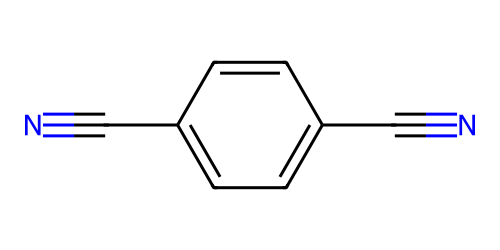

Aromatic: C1=CC(=CC=C1C#N)C#N
Kekule:   N#CC1=CC=C(C#N)C=C1

Structure of N#CC1=CC=C(C#N)C=C1


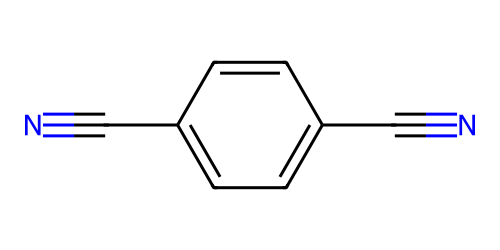

Aromatic: CNC1=CC2=C(C=C1)C=C(I)C=C2
Kekule:   CNC1=CC2=C(C=C1)C=C(I)C=C2

Structure of CNC1=CC2=C(C=C1)C=C(I)C=C2


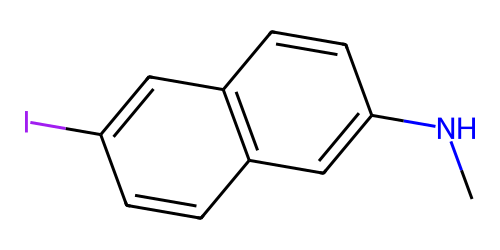

Aromatic: C1=CC2=C(C=CC3=C2C=CC(=C3)I)C=C1I
Kekule:   IC1=CC2=C(C=C1)C1=C(C=C2)C=C(I)C=C1

Structure of IC1=CC2=C(C=C1)C1=C(C=C2)C=C(I)C=C1


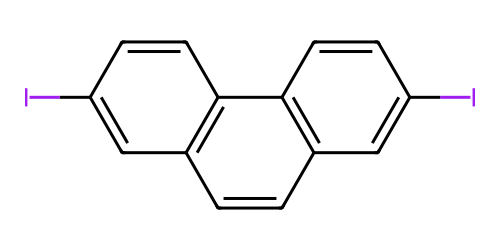

Aromatic: C1=CC2=C(C=C1I)C=C(I)C=C2I
Kekule:   IC1=CC2=C(C=C1)C(I)=CC(I)=C2

Structure of IC1=CC2=C(C=C1)C(I)=CC(I)=C2


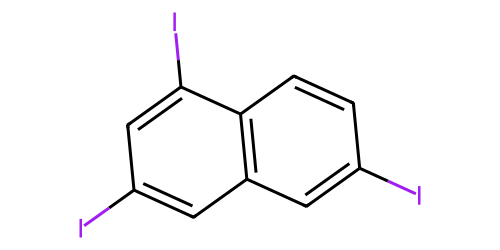

In [11]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display, Image
# 示例 SMILES（芳香式）
aromatic_smiles = ft_generated_smiles
def de_aromatize_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    try:
        # 执行反芳香化
        Chem.Kekulize(mol, clearAromaticFlags=True)
        # 转换为显式键的 SMILES（非芳香式）
        return Chem.MolToSmiles(mol, kekuleSmiles=True)
    except Exception as e:
        print(f"Failed to kekulize {smiles}: {e}")
        return None

# 批量转换并绘制高分辨率图像
for smi in aromatic_smiles:
    # 反芳香化
    kekule = de_aromatize_smiles(smi)
    print(f"Aromatic: {smi}\nKekule:   {kekule}\n")
    
    # 显示生成结构的高分辨率图像
    if kekule:
        print(f"Structure of {kekule}")
        mol2 = Chem.MolFromSmiles(kekule)
        
        # 使用 MolDraw2DCairo 生成高分辨率图像
        drawer = Draw.MolDraw2DCairo(500, 250)  # 设置画布尺寸
        options = drawer.drawOptions()
        options.minFontSize = 10
        options.bondLineWidth = 3
        options.padding = 0.05
        # 设置 DPI
        options.dpi = 300  # 设置 DPI 为 600（高分辨率）
        
        # 绘制分子
        drawer.DrawMolecule(mol2)
        drawer.FinishDrawing()

        # 获取绘制文本并显示图像
        img_data = drawer.GetDrawingText()
        img = Image(data=img_data)
        display(img)  # 直接显示图像在 Jupyter 输出框中


Aromatic: CC1=C(C(=C(C(=C1C)C=O)N=C=O)C)C
Kekule:   CC1=C(C)C(C)=C(N=C=O)C(C=O)=C1C

Structure of CC1=C(C)C(C)=C(N=C=O)C(C=O)=C1C


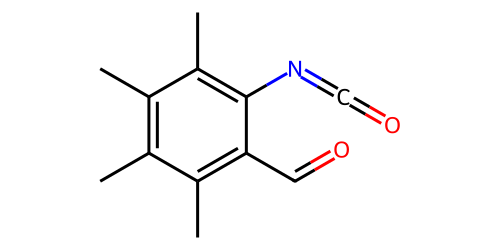

Aromatic: C1=CC=NC(=C1)C2=CC=NC=C2
Kekule:   C1=CC=C(C2=CC=NC=C2)N=C1

Structure of C1=CC=C(C2=CC=NC=C2)N=C1


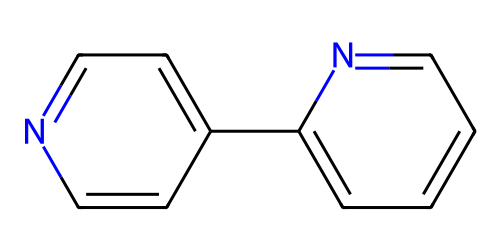

Aromatic: CC1=C(C(=C(C(=C1C2=CC=CC=C2)C)C)C=C)C=C CNN
Kekule:   C=CC1=C(C)C(C)=C(C2=CC=CC=C2)C(C)=C1C=C

Structure of C=CC1=C(C)C(C)=C(C2=CC=CC=C2)C(C)=C1C=C


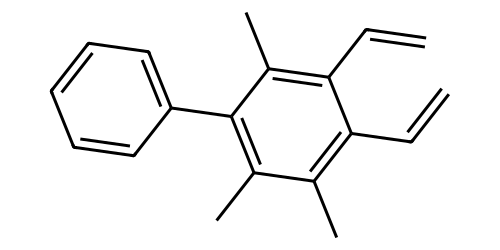

Aromatic: C1=CC=C(C=C1)C2=CC=CC=C2
Kekule:   C1=CC=C(C2=CC=CC=C2)C=C1

Structure of C1=CC=C(C2=CC=CC=C2)C=C1


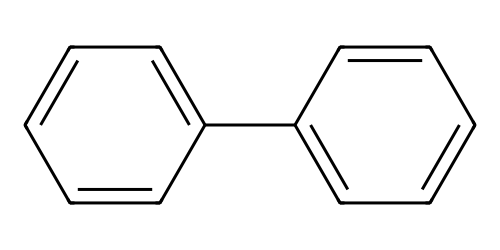

Aromatic: C1=CC=C(C=C1)C2=CC=CC=C2
Kekule:   C1=CC=C(C2=CC=CC=C2)C=C1

Structure of C1=CC=C(C2=CC=CC=C2)C=C1


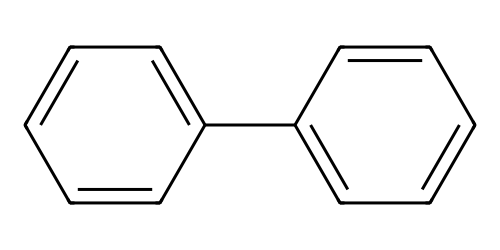

Aromatic: C1=CC(=CC=C1C2=CC=C(C=C2)OC3=CC=C(C=C3)C(=O)O)C4=CC=CC=C4
Kekule:   O=C(O)C1=CC=C(OC2=CC=C(C3=CC=C(C4=CC=CC=C4)C=C3)C=C2)C=C1

Structure of O=C(O)C1=CC=C(OC2=CC=C(C3=CC=C(C4=CC=CC=C4)C=C3)C=C2)C=C1


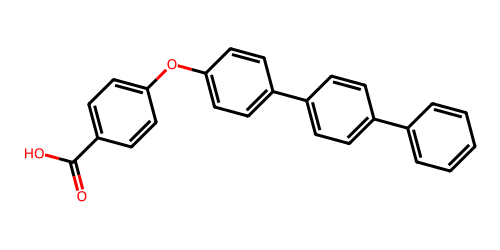

Aromatic: C1=CC=C2C(=C1)C(=O)C3=CC=CC=C3S(=O)(=O)O
Kekule:   None

Aromatic: C[C@H]1[C@@H]([C@H]([C@H]([C@@H](O1)NS(=O)(=O)C2=CC=CC=C2)C(=O)O)N
Kekule:   None

Aromatic: C1=CC=C2C(=C1)C=CC(=O)CCC2=C1
Kekule:   None

Aromatic: C1=CC=C(C=C1)N
Kekule:   NC1=CC=CC=C1

Structure of NC1=CC=CC=C1


[22:43:58] SMILES Parse Error: unclosed ring for input: 'C1=CC=C2C(=C1)C(=O)C3=CC=CC=C3S(=O)(=O)O'
[22:43:58] SMILES Parse Error: extra open parentheses for input: 'C[C@H]1[C@@H]([C@H]([C@H]([C@@H](O1)NS(=O)(=O)C2=CC=CC=C2)C(=O)O)N'
[22:43:58] SMILES Parse Error: unclosed ring for input: 'C1=CC=C2C(=C1)C=CC(=O)CCC2=C1'


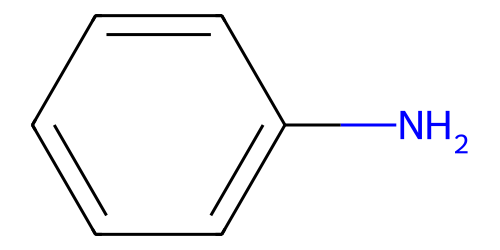

Aromatic: C1=CC=C(C=C1)C2=CC=C(C=C2)N
Kekule:   NC1=CC=C(C2=CC=CC=C2)C=C1

Structure of NC1=CC=C(C2=CC=CC=C2)C=C1


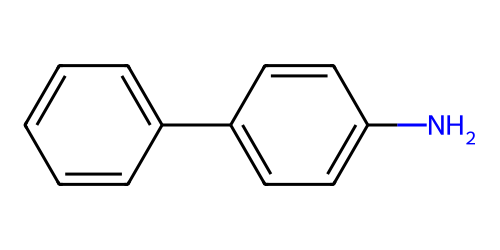

Aromatic: C1=CC=C(C=C1)C2=CC=C(C=C2)N
Kekule:   NC1=CC=C(C2=CC=CC=C2)C=C1

Structure of NC1=CC=C(C2=CC=CC=C2)C=C1


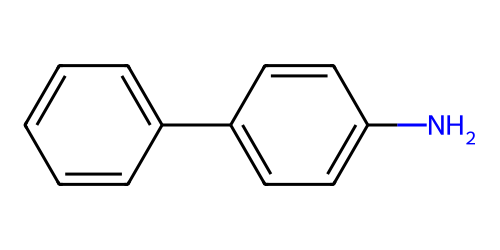

Aromatic: CSC1=CC=C(C=C1)SC2=CC=CC=C2C(=O)O
Kekule:   CSC1=CC=C(SC2=CC=CC=C2C(=O)O)C=C1

Structure of CSC1=CC=C(SC2=CC=CC=C2C(=O)O)C=C1


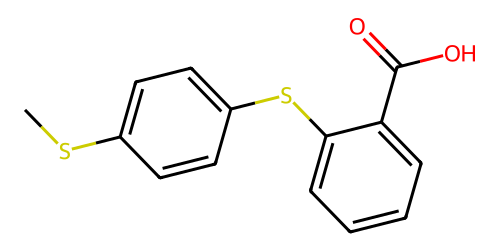

Aromatic: CSCCCCCCCCCCN1C2=CC=CC=C2C(=C1)SC
Kekule:   CSCCCCCCCCCCN1C=C(SC)C2=CC=CC=C21

Structure of CSCCCCCCCCCCN1C=C(SC)C2=CC=CC=C21


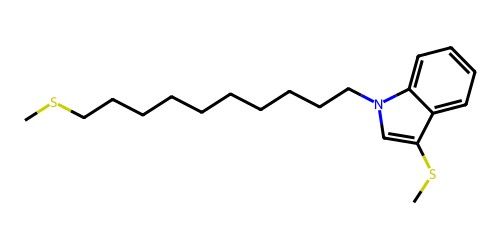

Aromatic: CSCCC[C@@H](C(=O)O)N
Kekule:   CSCCC[C@H](N)C(=O)O

Structure of CSCCC[C@H](N)C(=O)O


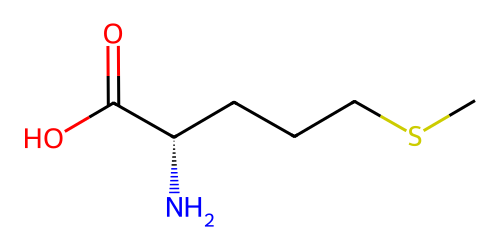

Aromatic: C1=CC(=CN=C1)C2=CC(=CC=C2)S(=O)(=O)N
Kekule:   NS(=O)(=O)C1=CC=CC(C2=CN=CC=C2)=C1

Structure of NS(=O)(=O)C1=CC=CC(C2=CN=CC=C2)=C1


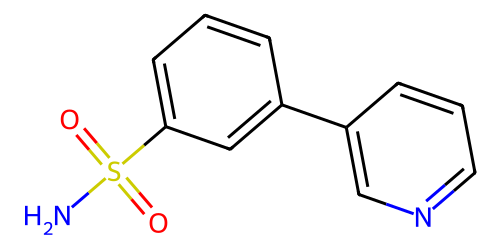

Aromatic: C1=CN=CC=C1S(=O)(=O)C2=CC=C(C=C2)N3CCCCC3
Kekule:   O=S(=O)(C1=CC=NC=C1)C1=CC=C(N2CCCCC2)C=C1

Structure of O=S(=O)(C1=CC=NC=C1)C1=CC=C(N2CCCCC2)C=C1


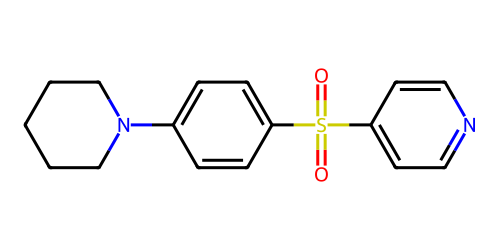

Aromatic: C1=CC=C2C(=C1)C(=O)N(C2=O)C(=O)O
Kekule:   O=C(O)N1C(=O)C2=CC=CC=C2C1=O

Structure of O=C(O)N1C(=O)C2=CC=CC=C2C1=O


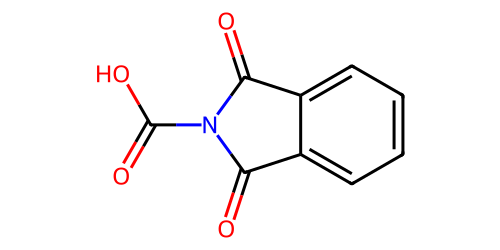

Aromatic: C1=CC=C2C(=C1)C(=O)C=C(N2)C3=CC=CC=N3
Kekule:   O=C1C=C(C2=CC=CC=N2)NC2=CC=CC=C12

Structure of O=C1C=C(C2=CC=CC=N2)NC2=CC=CC=C12


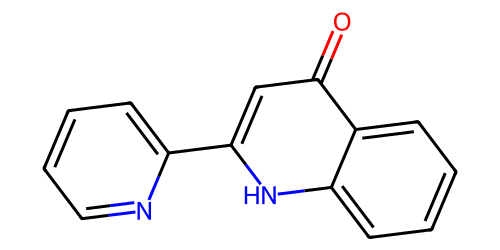

Aromatic: C1=CC(=CN=C1)C(=O)S
Kekule:   O=C(S)C1=CN=CC=C1

Structure of O=C(S)C1=CN=CC=C1


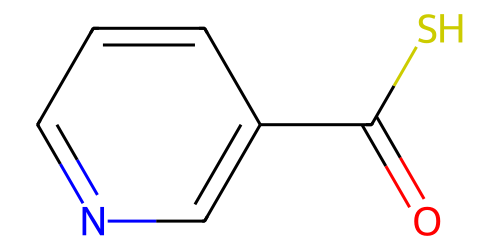

Aromatic: C1=CC=C(C=C1)S(=O)(=O)N
Kekule:   NS(=O)(=O)C1=CC=CC=C1

Structure of NS(=O)(=O)C1=CC=CC=C1


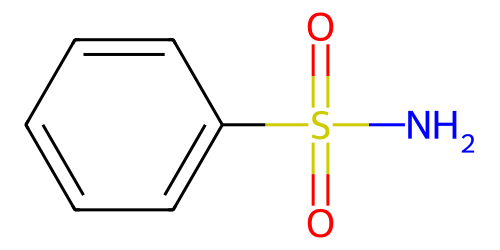

Aromatic: CNC1=CC=CC=C1
Kekule:   CNC1=CC=CC=C1

Structure of CNC1=CC=CC=C1


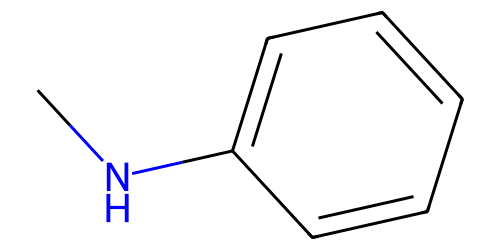

Aromatic: C1=CC=C(C=C1)CN
Kekule:   NCC1=CC=CC=C1

Structure of NCC1=CC=CC=C1


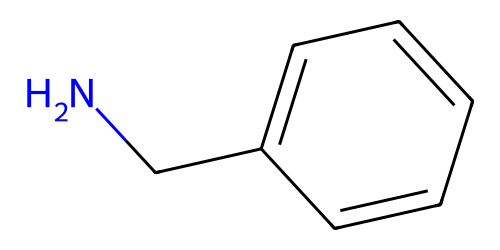

Aromatic: CNC1=CC=CC=C1
Kekule:   CNC1=CC=CC=C1

Structure of CNC1=CC=CC=C1


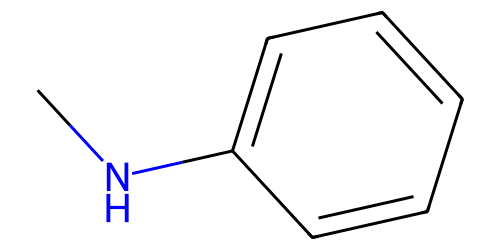

Aromatic: C1=CC=C(C=C1)C(=O)C2=CC=CC=C2
Kekule:   O=C(C1=CC=CC=C1)C1=CC=CC=C1

Structure of O=C(C1=CC=CC=C1)C1=CC=CC=C1


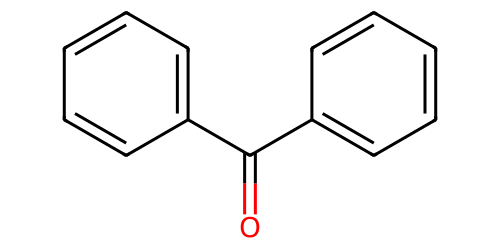

Aromatic: C1=CC=C(C=C1)C(=O)NC2=CC=CC=C2
Kekule:   O=C(NC1=CC=CC=C1)C1=CC=CC=C1

Structure of O=C(NC1=CC=CC=C1)C1=CC=CC=C1


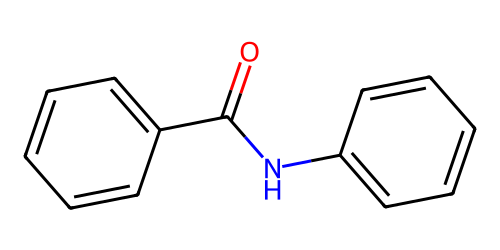

Aromatic: C1=CC=C(C=C1)C(=O)C2=CC=CC=C2
Kekule:   O=C(C1=CC=CC=C1)C1=CC=CC=C1

Structure of O=C(C1=CC=CC=C1)C1=CC=CC=C1


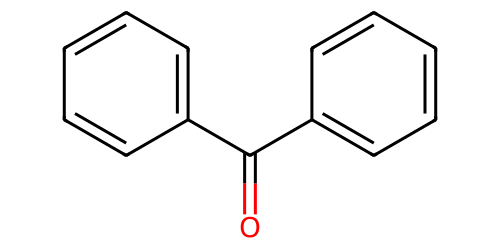

Aromatic: C1=CC=C2C(=C1)C=CC(=C2)I
Kekule:   IC1=CC2=CC=CC=C2C=C1

Structure of IC1=CC2=CC=CC=C2C=C1


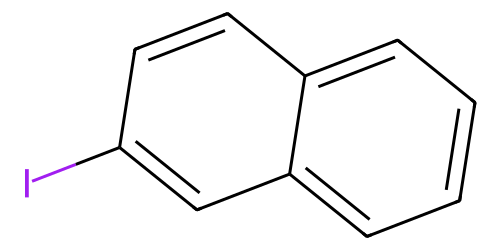

Aromatic: C1=CC=C2C(=C1)C=CC=C2I
Kekule:   IC1=CC=CC2=CC=CC=C12

Structure of IC1=CC=CC2=CC=CC=C12


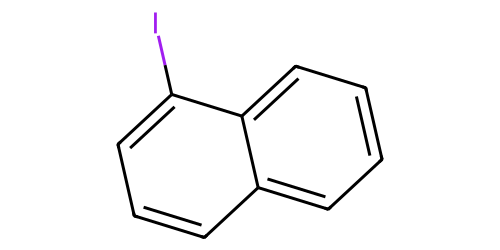

Aromatic: C1=CC=C(C=C1)C(=O)NCCCC3=CCCCC3
Kekule:   O=C(NCCCC1=CCCCC1)C1=CC=CC=C1

Structure of O=C(NCCCC1=CCCCC1)C1=CC=CC=C1


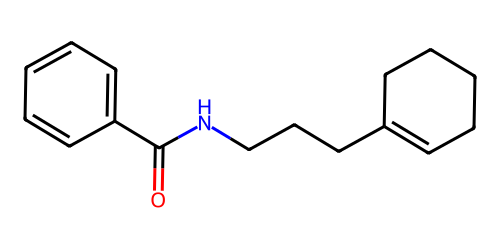

In [12]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display, Image
# 示例 SMILES（芳香式）
aromatic_smiles = mt5_generated_smiles
def de_aromatize_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    try:
        # 执行反芳香化
        Chem.Kekulize(mol, clearAromaticFlags=True)
        # 转换为显式键的 SMILES（非芳香式）
        return Chem.MolToSmiles(mol, kekuleSmiles=True)
    except Exception as e:
        print(f"Failed to kekulize {smiles}: {e}")
        return None

# 批量转换并绘制高分辨率图像
for smi in aromatic_smiles:
    # 反芳香化
    kekule = de_aromatize_smiles(smi)
    print(f"Aromatic: {smi}\nKekule:   {kekule}\n")
    
    # 显示生成结构的高分辨率图像
    if kekule:
        print(f"Structure of {kekule}")
        mol2 = Chem.MolFromSmiles(kekule)
        
        # 使用 MolDraw2DCairo 生成高分辨率图像
        drawer = Draw.MolDraw2DCairo(500, 250)  # 设置画布尺寸
        options = drawer.drawOptions()
        options.minFontSize = 10
        options.bondLineWidth = 3
        options.padding = 0.05
        # 设置 DPI
        options.dpi = 300  # 设置 DPI 为 600（高分辨率）
        
        # 绘制分子
        drawer.DrawMolecule(mol2)
        drawer.FinishDrawing()

        # 获取绘制文本并显示图像
        img_data = drawer.GetDrawingText()
        img = Image(data=img_data)
        display(img)  # 直接显示图像在 Jupyter 输出框中


Aromatic: CC1=CC=C(C=C1)C(=O)CC2=CC=CC=C2
Kekule:   CC1=CC=C(C(=O)CC2=CC=CC=C2)C=C1

Structure of CC1=CC=C(C(=O)CC2=CC=CC=C2)C=C1


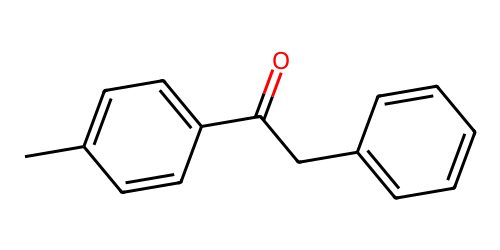

Aromatic: C1=CC=C(C=C1)C(=O)C2=CC=C(C=C2)N(C)C(=O)O
Kekule:   CN(C(=O)O)C1=CC=C(C(=O)C2=CC=CC=C2)C=C1

Structure of CN(C(=O)O)C1=CC=C(C(=O)C2=CC=CC=C2)C=C1


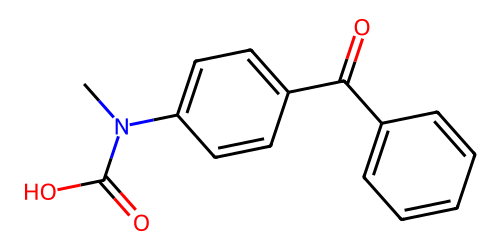

Aromatic: C1=CC=C(C=C1)C(=O)NC2=C(C=CC(=C2)C(=C3C=CC(=[N+](C)C)CC(=O)O)C4=CC=CC=C4
Kekule:   None

Aromatic: CC1=CC=C(C=C1)CCCC(=O)CC2=CC=CC=C2
Kekule:   CC1=CC=C(CCCC(=O)CC2=CC=CC=C2)C=C1

Structure of CC1=CC=C(CCCC(=O)CC2=CC=CC=C2)C=C1


[22:43:59] SMILES Parse Error: extra open parentheses for input: 'C1=CC=C(C=C1)C(=O)NC2=C(C=CC(=C2)C(=C3C=CC(=[N+](C)C)CC(=O)O)C4=CC=CC=C4'


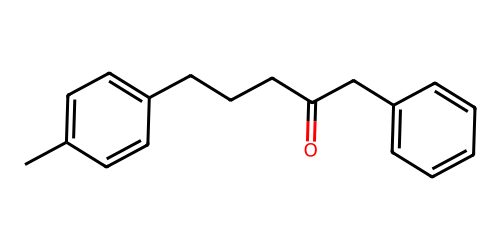

Aromatic: C1=CC=C(C=C1)CCC(=O)CCC2=CC=CC=C2
Kekule:   O=C(CCC1=CC=CC=C1)CCC1=CC=CC=C1

Structure of O=C(CCC1=CC=CC=C1)CCC1=CC=CC=C1


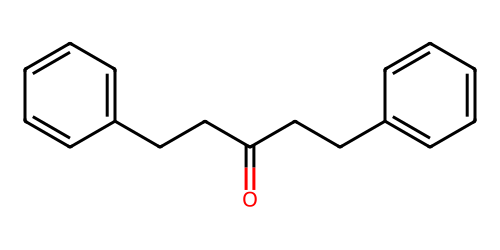

Aromatic: CC1=CC=C(C=C1)C(=O)C2=CC=CC=C2
Kekule:   CC1=CC=C(C(=O)C2=CC=CC=C2)C=C1

Structure of CC1=CC=C(C(=O)C2=CC=CC=C2)C=C1


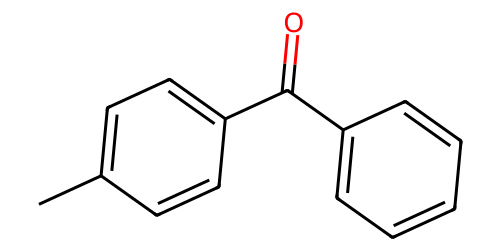

Aromatic: C1=CC2=C(C=C1S(=O)(=O)O)C(=C(C=C2S(=O)(=O)O)S(=O)(=O)O
Kekule:   None

Aromatic: C1=CC(=CC=C1C(=O)O)S(=O)(=O)O
Kekule:   O=C(O)C1=CC=C(S(=O)(=O)O)C=C1

Structure of O=C(O)C1=CC=C(S(=O)(=O)O)C=C1


[22:43:59] SMILES Parse Error: extra open parentheses for input: 'C1=CC2=C(C=C1S(=O)(=O)O)C(=C(C=C2S(=O)(=O)O)S(=O)(=O)O'


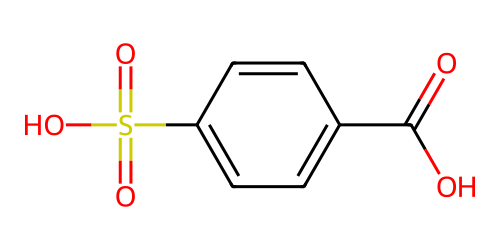

Aromatic: C1=CC=C2C(=C1)C(=O)C3=C(C2=O)C(=C(C=C3O)S(=O)(=O)O)S(=O)(=O)O)O
Kekule:   None

Aromatic: C1=CC=C(C=C1)C2=CC=CC=C2
Kekule:   C1=CC=C(C2=CC=CC=C2)C=C1

Structure of C1=CC=C(C2=CC=CC=C2)C=C1


[22:43:59] SMILES Parse Error: extra close parentheses while parsing: C1=CC=C2C(=C1)C(=O)C3=C(C2=O)C(=C(C=C3O)S(=O)(=O)O)S(=O)(=O)O)O
[22:43:59] SMILES Parse Error: Failed parsing SMILES 'C1=CC=C2C(=C1)C(=O)C3=C(C2=O)C(=C(C=C3O)S(=O)(=O)O)S(=O)(=O)O)O' for input: 'C1=CC=C2C(=C1)C(=O)C3=C(C2=O)C(=C(C=C3O)S(=O)(=O)O)S(=O)(=O)O)O'


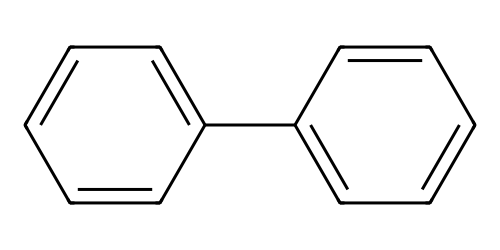

Aromatic: C1=CC=C(C=C1)C2=CC=C(C=C2)N)N
Kekule:   None

Aromatic: C1=CC=C(C=C1)C2=CC(=CC=C2)N2C3=CC=CC=C3
Kekule:   None

Aromatic: C=CCSC1=CC=CC=C1C(=O)[C@H](CSC2=CC=CC=C2)C(=O)O
Kekule:   C=CCSC1=CC=CC=C1C(=O)[C@H](CSC1=CC=CC=C1)C(=O)O

Structure of C=CCSC1=CC=CC=C1C(=O)[C@H](CSC1=CC=CC=C1)C(=O)O


[22:43:59] SMILES Parse Error: extra close parentheses while parsing: C1=CC=C(C=C1)C2=CC=C(C=C2)N)N
[22:43:59] SMILES Parse Error: Failed parsing SMILES 'C1=CC=C(C=C1)C2=CC=C(C=C2)N)N' for input: 'C1=CC=C(C=C1)C2=CC=C(C=C2)N)N'
[22:43:59] SMILES Parse Error: unclosed ring for input: 'C1=CC=C(C=C1)C2=CC(=CC=C2)N2C3=CC=CC=C3'


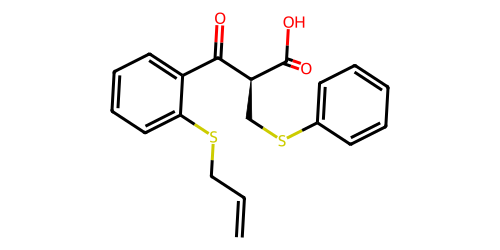

Aromatic: C[Sb](C)(C)C1=CC=C(C=C1)C(=O)O
Kekule:   C[Sb](C)(C)C1=CC=C(C(=O)O)C=C1

Structure of C[Sb](C)(C)C1=CC=C(C(=O)O)C=C1


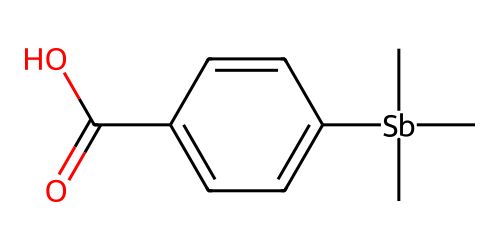

Aromatic: C=CCSC1=CC=CC=C1C(=O)N(C(=O)N(C(=O)N(C(=O)N)C(=O)O)C)C
Kekule:   C=CCSC1=CC=CC=C1C(=O)N(C)C(=O)N(C)C(=O)N(C(N)=O)C(=O)O

Structure of C=CCSC1=CC=CC=C1C(=O)N(C)C(=O)N(C)C(=O)N(C(N)=O)C(=O)O


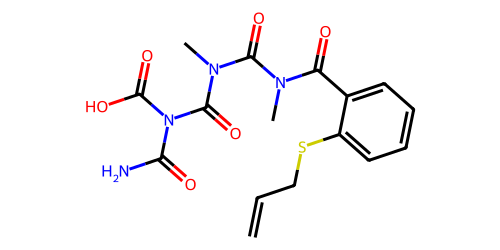

Aromatic: C1=CC(=CN=C1)C2=CC=CC=C2
Kekule:   C1=CC=C(C2=CN=CC=C2)C=C1

Structure of C1=CC=C(C2=CN=CC=C2)C=C1


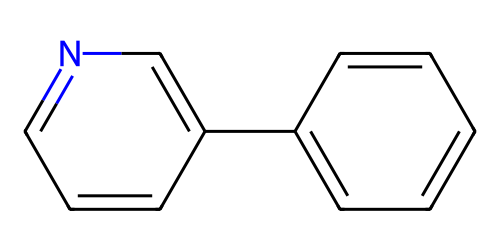

Aromatic: C1=CC(=NC2=C(C=C1)N=C(S2)C(=O)O
Kekule:   None

Aromatic: C1=CC(=CN=C1)C2=CC=CC=C2S(=O)(=O)O
Kekule:   O=S(=O)(O)C1=CC=CC=C1C1=CN=CC=C1

Structure of O=S(=O)(O)C1=CC=CC=C1C1=CN=CC=C1


[22:43:59] SMILES Parse Error: extra open parentheses for input: 'C1=CC(=NC2=C(C=C1)N=C(S2)C(=O)O'


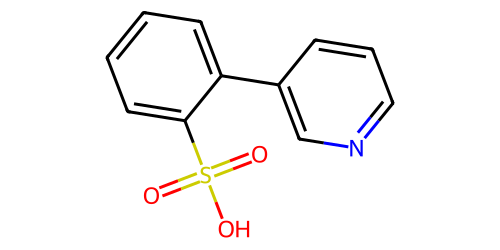

Aromatic: CC(=O)OC1=CC=C(C=C1)C(=O)[O-]
Kekule:   CC(=O)OC1=CC=C(C(=O)[O-])C=C1

Structure of CC(=O)OC1=CC=C(C(=O)[O-])C=C1


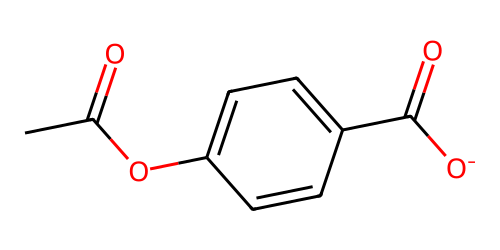

Aromatic: CSC1=C(C(=CC=C1)OC)C(=O)C2=CC=C(O2)C(=O)O
Kekule:   COC1=CC=CC(SC)=C1C(=O)C1=CC=C(C(=O)O)O1

Structure of COC1=CC=CC(SC)=C1C(=O)C1=CC=C(C(=O)O)O1


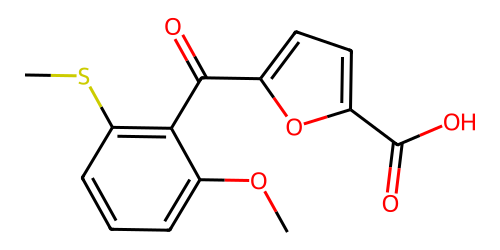

Aromatic: CCSC=NCC1=C(C(=C(C=N1)C)C(=O)[O-])C
Kekule:   CCSC=NCC1=C(C)C(C(=O)[O-])=C(C)C=N1

Structure of CCSC=NCC1=C(C)C(C(=O)[O-])=C(C)C=N1


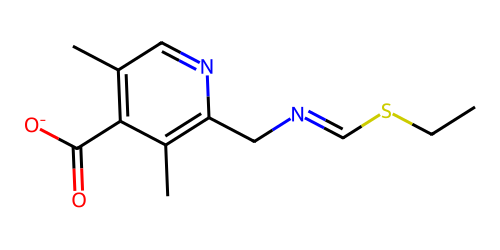

Aromatic: CC1=C(C(=CC=C1)C)C
Kekule:   CC1=CC=CC(C)=C1C

Structure of CC1=CC=CC(C)=C1C


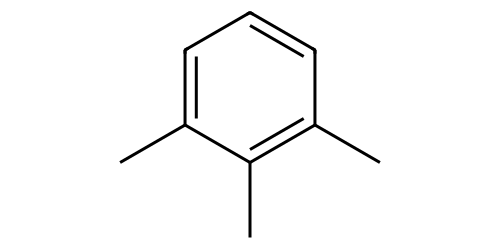

Aromatic: C[C@@H]1CCC(=O)C2=C(C3=C(C=C(C=C3C=C2
Kekule:   None

Aromatic: CN1C(=C(C2=C1C(=O)C3=CC=CC=C3N2) CNC2=O)C
Kekule:   None

Aromatic: C1=CC=C(C(=C1)C=O)[O-])C#N
Kekule:   None

Aromatic: [C-]#N.C1=CC2=C(C=C1)C=C(C=C2)C#N)C(=O)N
Kekule:   None

Aromatic: C1=CC=C(C=C1)CCCCCCC(=O)C2=CC=CC=C2
Kekule:   O=C(CCCCCCC1=CC=CC=C1)C1=CC=CC=C1

Structure of O=C(CCCCCCC1=CC=CC=C1)C1=CC=CC=C1


[22:43:59] SMILES Parse Error: extra open parentheses for input: 'C[C@@H]1CCC(=O)C2=C(C3=C(C=C(C=C3C=C2'
[22:43:59] SMILES Parse Error: extra open parentheses for input: 'CN1C(=C(C2=C1C(=O)C3=CC=CC=C3N2)'
[22:43:59] SMILES Parse Error: extra close parentheses while parsing: C1=CC=C(C(=C1)C=O)[O-])C#N
[22:43:59] SMILES Parse Error: Failed parsing SMILES 'C1=CC=C(C(=C1)C=O)[O-])C#N' for input: 'C1=CC=C(C(=C1)C=O)[O-])C#N'
[22:43:59] SMILES Parse Error: extra close parentheses while parsing: [C-]#N.C1=CC2=C(C=C1)C=C(C=C2)C#N)C(=O)N
[22:43:59] SMILES Parse Error: Failed parsing SMILES '[C-]#N.C1=CC2=C(C=C1)C=C(C=C2)C#N)C(=O)N' for input: '[C-]#N.C1=CC2=C(C=C1)C=C(C=C2)C#N)C(=O)N'


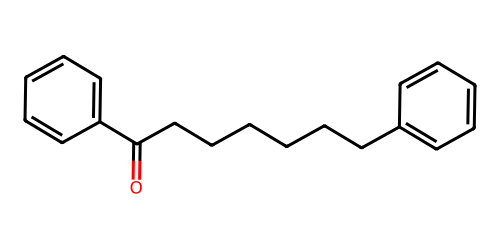

Aromatic: C1=CC=C2C(=C1)C=CC(=C2)I
Kekule:   IC1=CC2=CC=CC=C2C=C1

Structure of IC1=CC2=CC=CC=C2C=C1


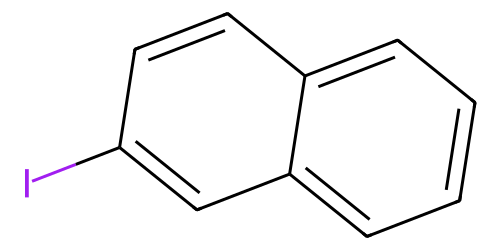

Aromatic: C1=CC=C(C(=C1)C(=O)C2=CC=CC=C2I
Kekule:   None

Aromatic: C1=CC=C2C(=C1)C=CC(=[N+]2=C3C=CC=C3I
Kekule:   None



[22:43:59] SMILES Parse Error: extra open parentheses for input: 'C1=CC=C(C(=C1)C(=O)C2=CC=CC=C2I'
[22:43:59] SMILES Parse Error: extra open parentheses for input: 'C1=CC=C2C(=C1)C=CC(=[N+]2=C3C=CC=C3I'


In [13]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display, Image
# 示例 SMILES（芳香式）
aromatic_smiles = t5_generated_smiles
def de_aromatize_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    try:
        # 执行反芳香化
        Chem.Kekulize(mol, clearAromaticFlags=True)
        # 转换为显式键的 SMILES（非芳香式）
        return Chem.MolToSmiles(mol, kekuleSmiles=True)
    except Exception as e:
        print(f"Failed to kekulize {smiles}: {e}")
        return None

# 批量转换并绘制高分辨率图像
for smi in aromatic_smiles:
    # 反芳香化
    kekule = de_aromatize_smiles(smi)
    print(f"Aromatic: {smi}\nKekule:   {kekule}\n")
    
    # 显示生成结构的高分辨率图像
    if kekule:
        print(f"Structure of {kekule}")
        mol2 = Chem.MolFromSmiles(kekule)
        
        # 使用 MolDraw2DCairo 生成高分辨率图像
        drawer = Draw.MolDraw2DCairo(500, 250)  # 设置画布尺寸
        options = drawer.drawOptions()
        options.minFontSize = 10
        options.bondLineWidth = 3
        options.padding = 0.05
        # 设置 DPI
        options.dpi = 300  # 设置 DPI 为 600（高分辨率）
        
        # 绘制分子
        drawer.DrawMolecule(mol2)
        drawer.FinishDrawing()

        # 获取绘制文本并显示图像
        img_data = drawer.GetDrawingText()
        img = Image(data=img_data)
        display(img)  # 直接显示图像在 Jupyter 输出框中
